# Preprocess

This notebook preprocesses the downloaded data.

## Settings

In [1]:
folder = '../../tmp/downloads' # stores downloads
dist_folder = '../../tmp/data' # stores outputs
data_sources_file = 'data.csv'
study_area_dataset = 'toronto' # bbox will be used as study area
force = False # whether to force processing
processed = {} # stores processed datasets

## Libraries

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np

from datetime import datetime, timedelta
from IPython.display import display, HTML
from pathlib import Path
from shapely.geometry import box, Point
from time import time

/Users/rrwen/Desktop/geointerv-paper/tmp/venv/lib/python3.9/site-packages/geopandas/_compat.py:123: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/var/folders/lg/1tfppccd38s1sn9w5z9g_mcm0000gn/T/ipykernel_77069/3063079617.py:2: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to S

## Classes

In [3]:
# For timing processes and displaying processing messages
class Timer:
    
    def __init__(self, name, process_name=None, start_prefix=None, end_prefix=None):
        self.name = name
        self.process_name = process_name
        self.start_prefix = start_prefix if start_prefix else 'Loading' if process_name.startswith('already') else 'Processing'
        self.end_prefix = end_prefix if end_prefix else 'Loaded' if process_name.startswith('already') else 'Processed'
    
    def start(self):
        self.start = time()
        self.start_dt = datetime.now()
        print(f'{self.start_prefix} {self.name} - {self.process_name} ({self.start_dt})...')
    
    def end(self):
        self.end = time()
        self.end_dt = datetime.now()
        self.elapsed = str(timedelta(seconds=self.end - self.start))
        print(f'{self.end_prefix} {self.name} - {self.process_name} ({self.end_dt}) [Elapsed: {self.elapsed}]')

## Functions

In [4]:
# Formats human readable sizes in bytes
# https://stackoverflow.com/questions/1094841/get-human-readable-version-of-file-size
def format_size(num, suffix="B"):
    for unit in ["", "Ki", "Mi", "Gi", "Ti", "Pi", "Ei", "Zi"]:
        if abs(num) < 1024.0:
            return f"{num:3.1f} {unit}{suffix}"
        num /= 1024.0
    return f"{num:.1f} Yi{suffix}"

# Extracts file info for summary
def file_info(file):
    stats = Path(file).stat()
    modified = datetime.fromtimestamp(stats.st_mtime)
    created = datetime.fromtimestamp(stats.st_birthtime)
    size = format_size(stats.st_size)
    out = {'created': created, 'modified': modified, 'size': size}
    return out

# Get basic info on a pandas dataframe
def df_info(df, name):
    memory = format_size(df.memory_usage().sum())
    cols = len(df.columns)
    rows = len(df)
    geometry = str(pd.unique(df.geometry.geom_type)) if 'geometry' in df else None
    out = {
        'dataset': name,
        'columns': cols,
        'rows': rows,
        'memory_usage': memory,
        'geometry': geometry
    }
    return out

# Read csv, shp, or geojson file into pandas or geopandas
def read_data(file, sheet_name=None, *args, **kwargs):
    path = Path(file)
    ext = path.suffix if path.suffix != '.zip' else path.suffixes[0]
    ext = ext.lower()
    if ext == '.csv':
        out = pd.read_csv(file, *args, **kwargs)
    elif ext in ['.xlsx', '.xls']:
        out = pd.read_excel(file, sheet_name=sheet_name, *args, **kwargs)
    elif ext in ['.geojson', '.shp']:
        out = gpd.read_file(file, *args, **kwargs)
    else:
        raise ValueError('File format not supported')
    return out

# Read data sources into pandas or geopandas datasets
def read_datasets(sources, folder=folder, *args, **kwargs):
    out = {}
    for row in sources.itertuples():
        
        # Define vars
        dataset = Path(row.file).with_suffix('').stem
        file = f'{folder}/{row.file}'
        
        # Start loading
        timer = Timer(file, 'read dataset', 'Loading', 'Loaded')
        timer.start()
        out[dataset] = read_data(file, *args, **kwargs)
        
        # End loading
        timer.end()
    return out

## Data

Read datasets from downloaded data files.

In [5]:
data_sources = read_data(data_sources_file)
datasets = read_datasets(data_sources)

Loading ../../tmp/downloads/toronto.geojson - read dataset (2025-01-20 19:21:32.081646)...
Loaded ../../tmp/downloads/toronto.geojson - read dataset (2025-01-20 19:21:52.579509) [Elapsed: 0:00:20.497863]
Loading ../../tmp/downloads/centrelines.geojson - read dataset (2025-01-20 19:21:52.579648)...
Loaded ../../tmp/downloads/centrelines.geojson - read dataset (2025-01-20 19:22:36.514435) [Elapsed: 0:00:43.934786]
Loading ../../tmp/downloads/collisions.geojson - read dataset (2025-01-20 19:22:36.514594)...
Loaded ../../tmp/downloads/collisions.geojson - read dataset (2025-01-20 19:25:43.490358) [Elapsed: 0:03:06.975755]
Loading ../../tmp/downloads/traffic.csv - read dataset (2025-01-20 19:25:43.490568)...
Loaded ../../tmp/downloads/traffic.csv - read dataset (2025-01-20 19:25:44.312626) [Elapsed: 0:00:00.822055]
Loading ../../tmp/downloads/autospeed_enforcement.geojson - read dataset (2025-01-20 19:25:44.312827)...
Loaded ../../tmp/downloads/autospeed_enforcement.geojson - read dataset (

Get the dataset for the study area:

<AxesSubplot:>

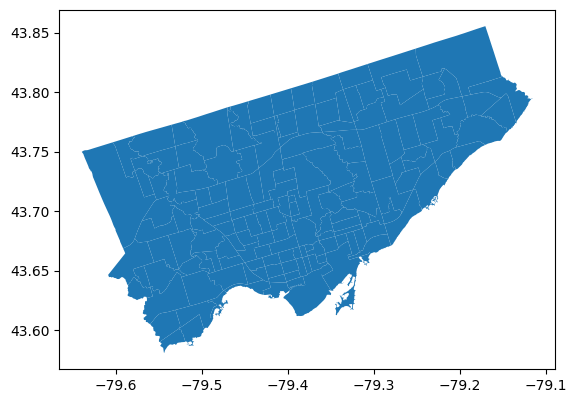

In [6]:
study_area = datasets[study_area_dataset]
study_area.plot()

## Run

Create folders to store processed data:

In [7]:
Path(dist_folder).mkdir(parents=True, exist_ok=True)
Path(f'{dist_folder}/clean-datasets').mkdir(parents=True, exist_ok=True)

The following datasets will be preprocessed:

In [8]:
info = pd.DataFrame([df_info(df, name) for name, df in datasets.items() if name != study_area_dataset])
info

,dataset,columns,rows,memory_usage,geometry
0,centrelines,41,65763,20.6 MiB,['MultiLineString']
1,collisions,22,704704,118.3 MiB,['Point']
2,traffic,60,224987,103.0 MiB,None
3,autospeed_enforcement,7,143,7.9 KiB,['MultiPoint']
4,watch_your_speed,14,1136,124.4 KiB,['MultiPoint']
5,red_light_cams,28,296,64.9 KiB,['MultiPoint']
6,police,7,26,1.5 KiB,['MultiPoint']
7,ambulance,26,46,9.5 KiB,['MultiPoint']
8,fire_hydrants,10,42670,3.3 MiB,['MultiPoint']
9,fire_stations,18,85,12.1 KiB,['MultiPoint']


Track processing time for all datasets and procedures:

In [9]:
gtimer = Timer('all datasets', 'preprocessing')
gtimer.start()

Processing all datasets - preprocessing (2025-01-20 19:28:30.424357)...


### Geodata Conversion

Convert longitude/latitude to point geometries:

In [10]:
# Start processing
timer = Timer('traffic', 'geoconversion')
timer.start()

# Convert coords to points
df = datasets['traffic']
datasets['traffic'] = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lng, df.lat),
    crs='EPSG:4326'
)

# End processing
timer.end()

Processing traffic - geoconversion (2025-01-20 19:28:30.429539)...
Processed traffic - geoconversion (2025-01-20 19:28:30.473713) [Elapsed: 0:00:00.044171]


In [11]:
datasets['traffic'].geometry

0         POINT (-79.39326 43.70528)
1         POINT (-79.39326 43.70528)
2         POINT (-79.39326 43.70528)
3         POINT (-79.39326 43.70528)
4         POINT (-79.39326 43.70528)
                     ...            
224982    POINT (-79.42188 43.65904)
224983    POINT (-79.42188 43.65904)
224984    POINT (-79.42188 43.65904)
224985    POINT (-79.42188 43.65904)
224986    POINT (-79.42188 43.65904)
Name: geometry, Length: 224987, dtype: geometry

### Extract Bounding Box

Get the bounding box from the `toronto` dataset:

In [12]:
# Start processing
timer = Timer('bbox', 'bbox extraction')
timer.start()

# Extract bbox
bbox = gpd.GeoSeries(box(*study_area.total_bounds), crs='EPSG:4326')

# End processing
timer.end()

Processing bbox - bbox extraction (2025-01-20 19:28:30.487390)...
Processed bbox - bbox extraction (2025-01-20 19:28:30.502378) [Elapsed: 0:00:00.014984]


<AxesSubplot:>

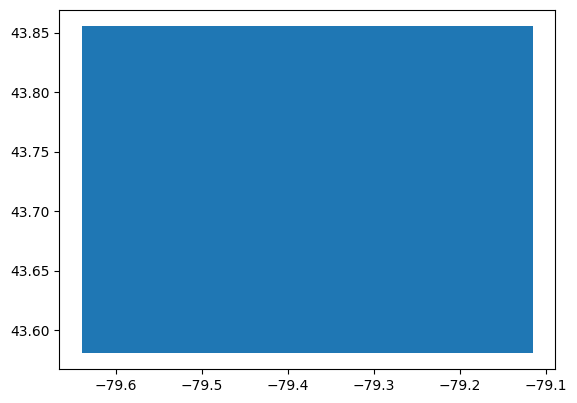

In [13]:
bbox.plot()

### Normalize Projections

Ensure that all datasets have the same projections as the study area `bbox`:

In [14]:
# Normalize projections
crs = bbox.estimate_utm_crs()
bbox = bbox.to_crs(crs)
for name, df in datasets.items():
    
    # Start processing
    timer = Timer(name, 'reprojection')
    timer.start()
    datasets[name] = df.to_crs(crs)
    
    # End processing
    timer.end()

Processing toronto - reprojection (2025-01-20 19:28:30.795240)...
Processed toronto - reprojection (2025-01-20 19:28:30.808601) [Elapsed: 0:00:00.013360]
Processing centrelines - reprojection (2025-01-20 19:28:30.808700)...
Processed centrelines - reprojection (2025-01-20 19:28:30.955920) [Elapsed: 0:00:00.147219]
Processing collisions - reprojection (2025-01-20 19:28:31.002185)...
Processed collisions - reprojection (2025-01-20 19:28:31.569642) [Elapsed: 0:00:00.567455]
Processing traffic - reprojection (2025-01-20 19:28:31.881173)...
Processed traffic - reprojection (2025-01-20 19:28:32.023792) [Elapsed: 0:00:00.142617]
Processing autospeed_enforcement - reprojection (2025-01-20 19:28:32.026858)...
Processed autospeed_enforcement - reprojection (2025-01-20 19:28:32.031503) [Elapsed: 0:00:00.004646]
Processing watch_your_speed - reprojection (2025-01-20 19:28:32.031782)...
Processed watch_your_speed - reprojection (2025-01-20 19:28:32.037657) [Elapsed: 0:00:00.005874]
Processing red_l

Check crs:

In [15]:
crs

<Projected CRS: EPSG:32617>
Name: WGS 84 / UTM zone 17N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 84°W and 78°W, northern hemisphere between equator and 84°N, onshore and offshore. Bahamas. Ecuador - north of equator. Canada - Nunavut; Ontario; Quebec. Cayman Islands. Colombia. Costa Rica. Cuba. Jamaica. Nicaragua. Panama. United States (USA).
- bounds: (-84.0, 0.0, -78.0, 84.0)
Coordinate Operation:
- name: UTM zone 17N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Display projected crs:

In [16]:
proj = pd.DataFrame(
    [{'dataset': name, 'projected_crs': str(df.crs)} for name, df in datasets.items() if name != study_area_dataset]
)
proj

,dataset,projected_crs
0,centrelines,EPSG:32617
1,collisions,EPSG:32617
2,traffic,EPSG:32617
3,autospeed_enforcement,EPSG:32617
4,watch_your_speed,EPSG:32617
5,red_light_cams,EPSG:32617
6,police,EPSG:32617
7,ambulance,EPSG:32617
8,fire_hydrants,EPSG:32617
9,fire_stations,EPSG:32617


### Clip Data

Clip data to study area bounds:

In [17]:
# Clip datasets to study area bbox
for name, df in datasets.items():
        
    # Start processing
    timer = Timer(name, 'clip')
    timer.start()

    # Clip data to study area
    datasets[name] = df.clip(bbox, keep_geom_type=True)

    # End processing
    timer.end()

Processing toronto - clip (2025-01-20 19:28:32.847875)...
Processed toronto - clip (2025-01-20 19:28:32.873226) [Elapsed: 0:00:00.025352]
Processing centrelines - clip (2025-01-20 19:28:32.873499)...
Processed centrelines - clip (2025-01-20 19:28:34.175944) [Elapsed: 0:00:01.302444]
Processing collisions - clip (2025-01-20 19:28:34.236902)...
Processed collisions - clip (2025-01-20 19:28:35.414686) [Elapsed: 0:00:01.177783]
Processing traffic - clip (2025-01-20 19:28:35.645624)...
Processed traffic - clip (2025-01-20 19:28:35.919796) [Elapsed: 0:00:00.274171]
Processing autospeed_enforcement - clip (2025-01-20 19:28:35.922920)...
Processed autospeed_enforcement - clip (2025-01-20 19:28:35.927038) [Elapsed: 0:00:00.004120]
Processing watch_your_speed - clip (2025-01-20 19:28:35.927186)...
Processed watch_your_speed - clip (2025-01-20 19:28:35.935645) [Elapsed: 0:00:00.008458]
Processing red_light_cams - clip (2025-01-20 19:28:35.936370)...
Processed red_light_cams - clip (2025-01-20 19:

In [18]:
# Calculate info for clipped datasets
info_clip = pd.DataFrame([df_info(df, name) for name, df in datasets.items() if name != study_area_dataset])

# Calculate difference in cols and rows from clip
info_diff = info[['columns', 'rows']] - info_clip[['columns', 'rows']]

# Add original datasets info
info_diff = pd.concat([info[['columns', 'rows', 'memory_usage', 'geometry']], info_diff], axis=1)
info_diff.columns = ['columns_orig', 'rows_orig', 'memory_usage_orig', 'geometry_orig', 'columns_diff', 'rows_diff']

# Add clipped datasets info
info_diff = pd.concat([info_clip, info_diff], axis=1)
info_diff

,dataset,columns,rows,memory_usage,geometry,columns_orig,rows_orig,memory_usage_orig,geometry_orig,columns_diff,rows_diff
0,centrelines,41,65763,21.1 MiB,['LineString' 'MultiLineString'],41,65763,20.6 MiB,['MultiLineString'],0,0
1,collisions,22,588876,103.3 MiB,['Point'],22,704704,118.3 MiB,['Point'],0,115828
2,traffic,61,224987,106.4 MiB,['Point'],60,224987,103.0 MiB,None,-1,0
3,autospeed_enforcement,7,143,8.9 KiB,['Point'],7,143,7.9 KiB,['MultiPoint'],0,0
4,watch_your_speed,14,1136,133.1 KiB,['Point'],14,1136,124.4 KiB,['MultiPoint'],0,0
5,red_light_cams,28,296,67.1 KiB,['Point'],28,296,64.9 KiB,['MultiPoint'],0,0
6,police,7,26,1.6 KiB,['Point'],7,26,1.5 KiB,['MultiPoint'],0,0
7,ambulance,26,46,9.7 KiB,['Point'],26,46,9.5 KiB,['MultiPoint'],0,0
8,fire_hydrants,10,42670,3.6 MiB,['Point'],10,42670,3.3 MiB,['MultiPoint'],0,0
9,fire_stations,18,85,12.6 KiB,['Point'],18,85,12.1 KiB,['MultiPoint'],0,0


**Note**: the `-1` in `columns_diff` resulted from an added `geometry` column by converting the non-spatial coordinates to point geometries 

### Study Area

Save the study area to the datasets folder.

In [19]:
file = Path(f'{dist_folder}/clean-datasets/{study_area_dataset}.geojson')
if not file.is_file() or force:
    datasets[study_area_dataset].to_file(file)

### Manual Geometry Extraction

Extract only the geometries for selected datasets - discarding all other attributes as only counts are needed.

In [20]:
to_extract = [
    'autospeed_enforcement',
    'red_light_cams',
    'police',
    'ambulance',
    'fire_hydrants',
    'fire_stations',
    'renewables',
    'bicycle_parking',
    'transit_shelters',
    'wayfind',
    'litter',
    'art',
    'culture',
    'religious'
]

for name in to_extract:
    
    file = Path(f'{dist_folder}/clean-datasets/{name}.geojson')
    if not file.is_file() or force:

        # Start processing
        timer = Timer(name, 'geometry extract')
        timer.start()
        gdf = datasets[name]

        # Extract geometry only
        gdf = gdf[['geometry']]

        # Save data
        gdf.to_file(file)

        # End processing
        timer.end()

    else:

        # Start loading
        timer = Timer(name, 'already extracted')
        timer.start()

        # Read clean data
        gdf = read_data(file)

        # End processing
        timer.end()

    processed[name] = gdf
    
processed['religious']

Processing autospeed_enforcement - geometry extract (2025-01-20 19:28:37.661822)...
Processed autospeed_enforcement - geometry extract (2025-01-20 19:28:37.677360) [Elapsed: 0:00:00.015536]
Processing red_light_cams - geometry extract (2025-01-20 19:28:37.677443)...
Processed red_light_cams - geometry extract (2025-01-20 19:28:37.701656) [Elapsed: 0:00:00.024210]
Processing police - geometry extract (2025-01-20 19:28:37.701740)...
Processed police - geometry extract (2025-01-20 19:28:37.707845) [Elapsed: 0:00:00.006105]
Processing ambulance - geometry extract (2025-01-20 19:28:37.707889)...
Processed ambulance - geometry extract (2025-01-20 19:28:37.714987) [Elapsed: 0:00:00.007098]
Processing fire_hydrants - geometry extract (2025-01-20 19:28:37.715035)...
Processed fire_hydrants - geometry extract (2025-01-20 19:28:40.262079) [Elapsed: 0:00:02.547042]
Processing fire_stations - geometry extract (2025-01-20 19:28:40.262424)...
Processed fire_stations - geometry extract (2025-01-20 19:

,geometry
280,POINT (617655.986 4827315.786)
281,POINT (618384.811 4827785.108)
282,POINT (618702.504 4827845.270)
115,POINT (618011.257 4827850.830)
288,POINT (618804.006 4827997.771)
...,...
502,POINT (638386.092 4853990.843)
503,POINT (638386.092 4853990.843)
1382,POINT (639356.271 4854162.590)
1383,POINT (639467.195 4854295.261)


### Manual Cleaning

Clean each dataset based on context - removing unnecessary variables and converting data types.

**Note**: Will perform cleaning only if processed data does not exist in the `dist/clean-datasets` folder.

#### centrelines

1. Filter out needed columns
2. Strip left and right whitespace
3s. Rename cols to identify dataset

In [21]:
name = 'centrelines'
file = Path(f'{dist_folder}/clean-datasets/{name}.geojson')
if not file.is_file() or force:
    
    # Start processing
    timer = Timer(name, 'clean')
    timer.start()
    gdf = datasets[name]

    # Lowercase col names
    gdf = gdf.rename(str.lower, axis='columns')

    # 1. Filter cols needed
    gdf = gdf[[
        'feature_code_desc',
        'oneway_dir_code_desc',
        'geometry'
    ]]
    
    # 2. Strip left and right whitespace
    to_format = [
        'feature_code_desc',
        'oneway_dir_code_desc'
    ]
    for c in to_format:
        gdf[c] = gdf[c].str.lstrip().str.rstrip()

    # 3. Rename cols
    gdf.columns = [f'centrelines_{c.replace("_desc", "")}' if c != 'geometry' else c for c in gdf.columns]

    # Save data
    gdf.to_file(file)
    
    # End processing
    timer.end()

else:
    
    # Start loading
    timer = Timer(name, 'already cleaned')
    timer.start()

    # Read clean data
    gdf = read_data(file)

    # End processing
    timer.end()
    
processed[name] = gdf

Processing centrelines - clean (2025-01-20 19:28:42.564876)...
Processed centrelines - clean (2025-01-20 19:28:49.053195) [Elapsed: 0:00:06.488316]


In [22]:
processed['centrelines']

,centrelines_feature_code,centrelines_oneway_dir_code,geometry
23,Geostatistical line,Not One-Way,"LINESTRING (617561.232 4826410.659, 617582.707..."
52071,Major Shoreline,Not One-Way,"LINESTRING (617637.295 4826387.997, 617630.498..."
24,Major Shoreline,Not One-Way,"LINESTRING (617779.238 4826775.075, 617785.874..."
37426,Trail,Not One-Way,"LINESTRING (617729.229 4826879.000, 617731.879..."
38553,Trail,Not One-Way,"LINESTRING (617729.229 4826879.000, 617734.738..."
...,...,...,...
43783,Minor Arterial,Not One-Way,"LINESTRING (644734.702 4856623.232, 644785.673..."
43197,Local,Not One-Way,"LINESTRING (647346.861 4856618.350, 647296.547..."
43773,Local,Not One-Way,"LINESTRING (647296.547 4856757.173, 647295.057..."
44016,Minor Arterial,Not One-Way,"LINESTRING (646275.583 4857174.237, 646469.208..."


#### collisions

1. Filter out needed columns
2. Strip whitespace/capitalize
3. Convert yes/no to 1/0
4. Extract day of month
5. Rename columns to identify dataset

In [23]:
name = 'collisions'
file = Path(f'{dist_folder}/clean-datasets/{name}.geojson')
if not file.is_file() or force:
    
    # Start processing
    timer = Timer(name, 'clean')
    timer.start()
    gdf = datasets[name]

    # Lowercase col names
    gdf = gdf.rename(str.lower, axis='columns')

    # 1. Filter cols needed
    gdf = gdf[[
        'occ_month',
        'occ_dow',
        'occ_year',
        'occ_hour',
        'fatalities',
        'injury_collisions',
        'ftr_collisions', # fail to remain
        'pd_collisions', # property damage
        'geometry'
    ]]
    
    # 2. Strip whitespace and capitalize
    to_format = [
        'occ_dow',
        'occ_month'
    ]
    for c in to_format:
        gdf[c] = gdf[c].str.strip().str.capitalize()

    # 3a. Convert yes/no to 1/0
    convert_cols = [
        'injury_collisions',
        'ftr_collisions',
        'pd_collisions'
    ]
    convert = {c: gdf[c].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0) for c in convert_cols}

    # 3b. Assign conversions to data
    gdf = gdf.assign(**convert)

    # 4. Extract day of month
    occ__date = pd.to_datetime(
        datasets[name]['OCC_DATE'],
        infer_datetime_format=True
    )
    gdf.insert(1, 'occ_dom' , occ__date.dt.day)

    # 5. Rename cols
    gdf.columns = [f'collisions_{c.replace("_collisions", "")}' if c != 'geometry' else c for c in gdf.columns]

    # Save data
    gdf.to_file(file)
    
    # End processing
    timer.end()

else:
    
    # Start loading
    timer = Timer(name, 'already cleaned')
    timer.start()

    # Read clean data
    gdf = read_data(file)

    # End processing
    timer.end()
    
processed[name] = gdf

Processing collisions - clean (2025-01-20 19:28:49.074006)...
Processed collisions - clean (2025-01-20 19:29:48.108273) [Elapsed: 0:00:59.034266]


In [24]:
processed['collisions']

,collisions_occ_month,collisions_occ_dom,collisions_occ_dow,collisions_occ_year,collisions_occ_hour,collisions_fatalities,collisions_injury,collisions_ftr,collisions_pd,geometry
643680,November,14,Tuesday,2023,17,0,0,0,1,POINT (617828.121 4826981.345)
243805,August,10,Thursday,2017,16,0,0,1,0,POINT (617828.121 4826981.345)
649119,December,10,Sunday,2023,12,0,0,1,0,POINT (617828.121 4826981.345)
668128,March,23,Saturday,2024,17,0,1,0,0,POINT (617828.121 4826981.345)
73740,February,16,Monday,2015,8,0,0,1,0,POINT (617773.517 4827149.119)
...,...,...,...,...,...,...,...,...,...,...
506529,August,24,Tuesday,2021,18,0,0,0,1,POINT (649922.121 4851771.848)
514939,October,19,Tuesday,2021,18,0,0,0,1,POINT (649922.121 4851771.848)
154184,May,8,Sunday,2016,15,0,0,0,1,POINT (649922.121 4851771.848)
140032,February,16,Tuesday,2016,9,0,0,0,1,POINT (649922.121 4851771.848)


#### traffic

1. Filter out needed columns
2. Extract month, day, year of traffic counts
3. Rename columns to identify dataset

In [25]:
name = 'traffic'
file = Path(f'{dist_folder}/clean-datasets/{name}.geojson')
if not file.is_file() or force:
    
    # Start processing
    timer = Timer(name, 'clean')
    timer.start()
    gdf = datasets[name]

    # Lowercase col names
    gdf = gdf.rename(str.lower, axis='columns')

    # 1. Filter cols needed
    gdf = gdf[[
        'sb_cars_r', # southbound cars, turn right
        'sb_cars_t', # straight
        'sb_cars_l', # turn left
        'nb_cars_r', # northbound cars
        'nb_cars_t',
        'nb_cars_l',
        'wb_cars_r', # westbound cars
        'wb_cars_t',
        'wb_cars_l',
        'eb_cars_r', # eastbound cars
        'eb_cars_t',
        'eb_cars_l',
        'sb_truck_r', # southbound trucks
        'sb_truck_t',
        'sb_truck_l',
        'nb_truck_r', # northbound trucks
        'nb_truck_t',
        'nb_truck_l',
        'wb_truck_r', # westbound trucks
        'wb_truck_t',
        'wb_truck_l',
        'eb_truck_r', # eastbound trucks
        'eb_truck_t',
        'eb_truck_l',
        'sb_bus_r', # southbound buses
        'sb_bus_t',
        'sb_bus_l',
        'nb_bus_r', # northbound buses
        'nb_bus_t',
        'nb_bus_l',
        'wb_bus_r', # westbound buses
        'wb_bus_t',
        'wb_bus_l',
        'eb_bus_r', # eastbound buses
        'eb_bus_t',
        'eb_bus_l',
        'nx_peds', # north leg pedestrians
        'sx_peds', # south leg pedestrians
        'ex_peds', # east leg pedestrians
        'wx_peds', # west leg pedestrians
        'nx_bike', # bikes
        'sx_bike',
        'ex_bike',
        'wx_bike',
        'nx_other', # non-vehicle (skateboard, scooters)
        'sx_other',
        'ex_other',
        'wx_other',
        'geometry'
    ]]

    # 2. Extract month, day, year
    count_date = pd.to_datetime(
        datasets[name]['count_date'],
        infer_datetime_format=True
    )
    gdf.insert(0, 'year' , count_date.dt.year)
    gdf.insert(0, 'day_of_month' , count_date.dt.day)
    gdf.insert(0, 'month' , count_date.dt.month)

    # 3. Rename cols
    gdf.columns = [f'traffic_{c.replace("_collisions", "")}' if c != 'geometry' else c for c in gdf.columns]

    # Save data
    gdf.to_file(file)
    
    # End processing
    timer.end()

else:
    
    # Start loading
    timer = Timer(name, 'already cleaned')
    timer.start()

    # Read clean data
    gdf = read_data(file)

    # End processing
    timer.end()
    
processed[name] = gdf

Processing traffic - clean (2025-01-20 19:29:48.133593)...
Processed traffic - clean (2025-01-20 19:31:22.443156) [Elapsed: 0:01:34.309561]


In [26]:
processed['traffic']

,traffic_month,traffic_day_of_month,traffic_year,traffic_sb_cars_r,traffic_sb_cars_t,traffic_sb_cars_l,traffic_nb_cars_r,traffic_nb_cars_t,traffic_nb_cars_l,traffic_wb_cars_r,...,traffic_wx_peds,traffic_nx_bike,traffic_sx_bike,traffic_ex_bike,traffic_wx_bike,traffic_nx_other,traffic_sx_other,traffic_ex_other,traffic_wx_other,geometry
53449,4,25,2012,1.0,1.0,4.0,10.0,0.0,3.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,POINT (617457.161 4827422.427)
53457,4,25,2012,1.0,0.0,2.0,5.0,0.0,3.0,2.0,...,0.0,0.0,0.0,5.0,2.0,0.0,0.0,0.0,0.0,POINT (617457.161 4827422.427)
53459,4,25,2012,1.0,0.0,1.0,2.0,0.0,2.0,2.0,...,0.0,0.0,0.0,3.0,2.0,0.0,0.0,0.0,0.0,POINT (617457.161 4827422.427)
53460,4,25,2012,3.0,0.0,2.0,6.0,0.0,3.0,5.0,...,2.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,POINT (617457.161 4827422.427)
60854,8,30,2012,1.0,0.0,7.0,2.0,0.0,3.0,5.0,...,2.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,POINT (617457.161 4827422.427)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105749,4,29,2015,30.0,0.0,15.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,POINT (641066.590 4855376.231)
105750,4,29,2015,31.0,0.0,15.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,POINT (641066.590 4855376.231)
105751,4,29,2015,23.0,0.0,21.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,POINT (641066.590 4855376.231)
105752,4,29,2015,29.0,0.0,19.0,0.0,0.0,0.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,POINT (641066.590 4855376.231)


#### watch_your_speed

1. Filter out needed columns
2. Strip left and right whitespace
2. Rename cols to identify dataset

In [27]:
name = 'watch_your_speed'
file = Path(f'{dist_folder}/clean-datasets/{name}.geojson')
if not file.is_file() or force:
    
    # Start processing
    timer = Timer(name, 'clean')
    timer.start()
    gdf = datasets[name]

    # Lowercase col names
    gdf = gdf.rename(str.lower, axis='columns')

    # 1. Filter cols needed
    gdf = gdf[[
        'dir', # dir of travel
        'min_speed', # speed at which sign starts recording
        'speed_limit',
        'geometry'
    ]]
    
    # 2. Strip left and right whitespace
    to_format = ['dir']
    for c in to_format:
        gdf[c] = gdf[c].str.lstrip().str.rstrip()

    # 3. Rename cols
    gdf.columns = [f'wys_{c}' if c != 'geometry' else c for c in gdf.columns]

    # Save data
    gdf.to_file(file)
    
    # End processing
    timer.end()
    
else:
    
    # Start loading
    timer = Timer(name, 'already cleaned')
    timer.start()

    # Read clean data
    gdf = read_data(file)

    # End processing
    timer.end()
    
processed[name] = gdf

Processing watch_your_speed - clean (2025-01-20 19:31:22.506364)...
Processed watch_your_speed - clean (2025-01-20 19:31:22.605986) [Elapsed: 0:00:00.099620]


In [28]:
processed['watch_your_speed']

,wys_dir,wys_min_speed,wys_speed_limit,geometry
118,NB,20,30,POINT (618685.858 4827822.697)
619,NB,5,40,POINT (619788.800 4828082.946)
618,EB,30,50,POINT (619589.983 4828274.595)
113,WB,30,50,POINT (619596.527 4828297.042)
133,SB,30,50,POINT (619656.943 4828426.993)
...,...,...,...,...
1101,NB,5,40,POINT (639038.281 4853528.492)
265,,5,40,POINT (638450.730 4853927.694)
1096,NB,5,40,POINT (638453.691 4853932.312)
1093,SB,5,40,POINT (638374.387 4854090.111)


#### schools

1. Filter out needed columns
2. Strip left and right whitespace
3. Rename columns to identify dataset

In [29]:
name = 'schools'
file = Path(f'{dist_folder}/clean-datasets/{name}.geojson')
if not file.is_file() or force:
    
    # Start processing
    timer = Timer(name, 'clean')
    timer.start()
    gdf = datasets[name]
    
    # Lowercase col names
    gdf = gdf.rename(str.lower, axis='columns')

    # 1. Filter cols needed
    gdf = gdf[[
        'school_level',
        'school_type_desc',
        'geometry'
    ]]
    
    # 2. Strip left and right whitespace
    to_format = [
        'school_level',
        'school_type_desc',
    ]
    for c in to_format:
        gdf[c] = gdf[c].str.lstrip().str.rstrip()
    
    # 3. Rename cols
    gdf = gdf.rename(columns={
        'school_level': 'schools_level',
        'school_type_desc': 'schools_type'
    })

    # Save data
    gdf.to_file(file)
    
    # End processing
    timer.end()
    
else:
    
    # Start loading
    timer = Timer(name, 'already cleaned')
    timer.start()

    # Read clean data
    gdf = read_data(file)

    # End processing
    timer.end()
    
processed[name] = gdf

Processing schools - clean (2025-01-20 19:31:22.626709)...
Processed schools - clean (2025-01-20 19:31:22.725758) [Elapsed: 0:00:00.099046]


In [30]:
processed['schools']

,schools_level,schools_type,geometry
675,None,Private,POINT (618384.811 4827785.108)
515,None,English Public,POINT (618641.124 4827869.702)
363,None,English Separate,POINT (619741.624 4827976.711)
477,None,None,POINT (619434.035 4828177.362)
472,None,English Separate,POINT (619676.909 4828220.336)
...,...,...,...
50,None,Private,POINT (633994.306 4851998.156)
265,None,English Public,POINT (635294.270 4852056.133)
295,None,English Public,POINT (635163.526 4852382.972)
931,None,English Separate,POINT (634484.334 4852539.452)


#### childcare

1. Filter out needed columns
2. Strip left and right whitespace
3. Convert yes/no to 1/0
4. Rename columns to identify dataset

In [31]:
name = 'childcare'
file = Path(f'{dist_folder}/clean-datasets/{name}.geojson')
if not file.is_file() or force:
    
    # Start processing
    timer = Timer(name, 'clean')
    timer.start()
    gdf = datasets[name]
    
    # Lowercase col names
    gdf = gdf.rename(str.lower, axis='columns')

    # 1. Filter cols needed
    gdf = gdf[[
        'auspice', # operating auspice: commercial, nonprofit, public
        'bldg_type', # building type
        'igspace', # spaces for infants 0-18 months
        'tgspace', # spaces for toddlers 18-30 months
        'pgspace', # spaces for preschoolers 30 months+
        'kgspace', # spaces for children in full day kindergarten
        'sgspace', # spaces for children grade 1+
        'totspace', # total spaces for all age groups
        'subsidy', # centre has fee subsidy contract (y/n)
        'geometry'
    ]]
    
    # 2. Strip left and right whitespace
    to_format = [
        'auspice',
        'bldg_type',
        'subsidy'
    ]
    for c in to_format:
        gdf[c] = gdf[c].str.lstrip().str.rstrip()
    
    # 3. Convert yes/no to 1/0
    gdf = gdf.assign(
        subsidy=gdf['subsidy'].apply(lambda x: 1 if x.strip().lower() == 'y' else 0)
    )
    
    # 4. Rename cols
    gdf.columns = [f'childcare_{c.replace("_desc", "")}' if c != 'geometry' else c for c in gdf.columns]

    # Save data
    gdf.to_file(file)
    
    # End processing
    timer.end()
    
else:
    
    # Start loading
    timer = Timer(name, 'already cleaned')
    timer.start()

    # Read clean data
    gdf = read_data(file)

    # End processing
    timer.end()
    
processed[name] = gdf

Processing childcare - clean (2025-01-20 19:31:22.745557)...
Processed childcare - clean (2025-01-20 19:31:22.857450) [Elapsed: 0:00:00.111889]


In [32]:
processed['childcare']

,childcare_auspice,childcare_bldg_type,childcare_igspace,childcare_tgspace,childcare_pgspace,childcare_kgspace,childcare_sgspace,childcare_totspace,childcare_subsidy,geometry
756,Non Profit Agency,Public Middle School,0,0,0,13,30,43,1,POINT (618641.125 4827869.702)
410,Non Profit Agency,Other,0,0,16,0,0,16,0,POINT (620628.977 4827920.202)
310,Public (City Operated) Agency,Other,10,20,32,0,0,62,1,POINT (619574.314 4828218.620)
880,Non Profit Agency,Catholic Elementary School,0,0,0,39,75,114,1,POINT (619676.910 4828220.335)
98,Commercial Agency,Other,0,15,64,0,0,79,1,POINT (618783.788 4828256.584)
...,...,...,...,...,...,...,...,...,...,...
344,Non Profit Agency,Catholic Elementary School,0,0,24,0,15,39,1,POINT (644228.314 4853219.624)
1022,Non Profit Agency,Public Elementary School,0,0,0,13,15,28,1,POINT (642638.810 4853887.719)
927,Commercial Agency,Other,0,28,30,0,0,58,0,POINT (641764.229 4854076.924)
825,Non Profit Agency,Catholic Elementary School,0,0,0,26,30,56,1,POINT (642093.887 4854495.578)


#### crime

1. Filter out needed columns
2. Strip whitespace/capitalize
3. Rename columns to identify dataset

In [33]:
name = 'crime'
file = Path(f'{dist_folder}/clean-datasets/{name}.geojson')
if not file.is_file() or force:
    
    # Start processing
    timer = Timer(name, 'clean')
    timer.start()
    gdf = datasets[name]
    
    # Lowercase col names
    gdf = gdf.rename(str.lower, axis='columns')

    # 1. Filter cols needed
    gdf = gdf[[
        'division',
        'premises_type',
        'offence',
        'report_year',
        'report_month',
        'report_day',
        'report_doy',
        'report_dow',
        'report_hour',
        'occ_year',
        'occ_month',
        'occ_day',
        'occ_doy',
        'occ_dow',
        'occ_hour',
        'mci_category',
        'neighbourhood_158',
        'geometry'
    ]]
    
    # 2a. Strip whitespace
    to_format = [
        'report_dow',
        'report_month',
        'occ_month',
        'occ_dow'
    ]
    for c in to_format:
        gdf[c] = gdf[c].str.strip().str.capitalize()
        
    # 2b. Strip left and right whitespace
    to_format = [
        'division',
        'premises_type',
        'offence',
        'mci_category',
        'neighbourhood_158'   
    ]
    for c in to_format:
        gdf[c] = gdf[c].str.lstrip().str.rstrip()
    
    # 3. Rename cols
    gdf.columns = [f'crime_{c}' if c != 'geometry' else c for c in gdf.columns]

    # Save data
    gdf.to_file(file)
    
    # End processing
    timer.end()
    
else:
    
    # Start loading
    timer = Timer(name, 'already cleaned')
    timer.start()

    # Read clean data
    gdf = read_data(file)

    # End processing
    timer.end()
    
processed[name] = gdf

Processing crime - clean (2025-01-20 19:31:22.909339)...
Processed crime - clean (2025-01-20 19:32:26.656761) [Elapsed: 0:01:03.747421]


In [34]:
processed['crime']

,crime_division,crime_premises_type,crime_offence,crime_report_year,crime_report_month,crime_report_day,crime_report_doy,crime_report_dow,crime_report_hour,crime_occ_year,crime_occ_month,crime_occ_day,crime_occ_doy,crime_occ_dow,crime_occ_hour,crime_mci_category,crime_neighbourhood_158,geometry
346305,D22,Outside,Assault With Weapon,2023,June,23,174,Friday,16,2023,June,23,174,Friday,11,Assault,Long Branch (19),POINT (617828.121 4826981.345)
265612,D22,Outside,Theft Of Motor Vehicle,2021,July,29,210,Thursday,21,2021,July,29,210,Thursday,12,Auto Theft,Long Branch (19),POINT (617713.271 4827078.482)
265208,D22,Outside,Assault,2021,July,25,206,Sunday,22,2021,July,25,206,Sunday,20,Assault,Long Branch (19),POINT (617713.271 4827078.482)
248822,D22,Outside,Theft Of Motor Vehicle,2021,January,26,26,Tuesday,16,2021,January,26,26,Tuesday,6,Auto Theft,Long Branch (19),POINT (617713.271 4827078.482)
200895,D22,Apartment,B&E,2019,September,27,270,Friday,12,2019,September,22,265,Sunday,20,Break and Enter,Long Branch (19),POINT (617713.271 4827078.482)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188112,D42,Outside,Theft Of Motor Vehicle,2019,June,11,162,Tuesday,8,2019,June,10,161,Monday,21,Auto Theft,NSA,POINT (646275.991 4857174.113)
32137,D53,Apartment,Assault,2014,December,27,361,Saturday,13,2014,December,22,356,Monday,16,Assault,NSA,POINT (646275.991 4857174.113)
239481,D42,Outside,Theft Of Motor Vehicle,2020,October,12,286,Monday,8,2020,October,11,285,Sunday,19,Auto Theft,Morningside Heights (144),POINT (646275.991 4857174.113)
239480,D42,Outside,Theft Of Motor Vehicle,2020,October,12,286,Monday,8,2020,October,11,285,Sunday,19,Auto Theft,Morningside Heights (144),POINT (646275.991 4857174.113)


## Summary

In [35]:
gtimer.end()

Processed all datasets - preprocessing (2025-01-20 19:32:26.680510) [Elapsed: 0:03:56.256153]


The following datasets were processed:

In [36]:
info = pd.DataFrame([df_info(df, name) for name, df in processed.items()])
info

,dataset,columns,rows,memory_usage,geometry
0,autospeed_enforcement,1,143,2.2 KiB,['Point']
1,red_light_cams,1,296,4.6 KiB,['Point']
2,police,1,26,416.0 B,['Point']
3,ambulance,1,46,736.0 B,['Point']
4,fire_hydrants,1,42670,666.7 KiB,['Point']
5,fire_stations,1,85,1.3 KiB,['Point']
6,renewables,1,100,1.6 KiB,['Point']
7,bicycle_parking,1,17499,273.4 KiB,['Point']
8,transit_shelters,1,5939,92.8 KiB,['Point']
9,wayfind,1,387,6.0 KiB,['Point']


Each clean dataset was saved to file:

In [37]:
# Copy data sources to use in summary
summary = data_sources.copy().drop(0).reset_index()

# Get clean dataset file paths
clean_files = [Path(row.file).with_suffix('').stem for row in summary.itertuples() if Path(row.file).stem != study_area_dataset]
clean_files = [f'{dist_folder}/clean-datasets/{f}.geojson' for f in clean_files]
summary['file'] = clean_files

# Get file infos and add to summary
info = [file_info(f) for f in clean_files]
info = pd.DataFrame(info)
summary = pd.concat([summary, info], axis=1)

# Rearrange summary columns and display
summary = summary.rename(columns={'url': 'raw_url'})
summary = summary[['file', 'size', 'created', 'modified', 'source', 'source_url', 'raw_url']]
display(HTML(summary.to_html(render_links=True)))

,file,size,created,modified,source,source_url,raw_url
0,../../tmp/data/clean-datasets/centrelines.geojson,35.0 MiB,2025-01-20 19:28:42.714744,2025-01-20 19:28:49.044108,City of Toronto Open Data Portal,https://open.toronto.ca/dataset/toronto-centreline-tcl/,https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/1d079757-377b-4564-82df-eb5638583bfb/resource/7bc94ccf-7bcf-4a7d-88b1-bdfc8ec5aaf1/download/Centreline%20-%20Version%202%20-%204326.geojson
1,../../tmp/data/clean-datasets/collisions.geojson,217.7 MiB,2025-01-20 19:28:54.305730,2025-01-20 19:29:48.098426,Toronto Police Service Public Safety Data Portal,https://data.torontopolice.on.ca/datasets/TorontoPS::traffic-collisions-open-data-asr-t-tbl-001/about,https://stg-arcgisazurecdataprod.az.arcgis.com/exportfiles-6104-20398/Traffic_Collisions_Open_Data_-6024052409346627848.geojson?sv=2018-03-28&sr=b&sig=T%2FtlvA7HFHIHAPCJuiKXMSsqhHvJ8472JrgX7vF8x0o%3D&se=2025-01-21T01%3A07%3A03Z&sp=r
2,../../tmp/data/clean-datasets/traffic.geojson,310.8 MiB,2025-01-20 19:29:48.249621,2025-01-20 19:31:22.433684,City of Toronto Open Data Portal,https://open.toronto.ca/dataset/traffic-volumes-at-intersections-for-all-modes/,https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/traffic-volumes-at-intersections-for-all-modes/resource/1f60c668-bb8e-4e1e-ac72-3c6558a03fea/download/raw-data-2010-2019.csv
3,../../tmp/data/clean-datasets/autospeed_enforcement.geojson,20.1 KiB,2025-01-20 19:28:37.666329,2025-01-20 19:28:37.677264,City of Toronto Open Data Portal,https://open.toronto.ca/dataset/automated-speed-enforcement-locations/,https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/a154790c-4a8a-4d09-ab6b-535ddb646770/resource/9842895b-2b8b-4b60-9320-c0a1fde4afd8/download/Automated%20Speed%20Enforcement%20Locations%20-%204326.geojson
4,../../tmp/data/clean-datasets/watch_your_speed.geojson,229.0 KiB,2025-01-20 19:31:22.514872,2025-01-20 19:31:22.603915,City of Toronto Open Data Portal,https://open.toronto.ca/dataset/school-safety-zone-watch-your-speed-program-locations/,https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/642efeca-1258-4c23-8e86-d9affca26001/resource/b3268057-6b55-4e6e-b1ae-b752bce92a1c/download/Stationary%20Sign%20locations%20-%204326.geojson
5,../../tmp/data/clean-datasets/red_light_cams.geojson,41.4 KiB,2025-01-20 19:28:37.681474,2025-01-20 19:28:37.701538,City of Toronto Open Data Portal,https://open.toronto.ca/dataset/red-light-cameras/,https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/9fcff3e1-3737-43cf-b410-05acd615e27b/resource/7e4ac806-4e7a-49d3-81e1-7a14375c9025/download/Red%20Light%20Cameras%20Data%20-%204326.geojson
6,../../tmp/data/clean-datasets/police.geojson,3.8 KiB,2025-01-20 19:28:37.705189,2025-01-20 19:28:37.707809,City of Toronto Open Data Portal,https://open.toronto.ca/dataset/police-facility-locations/,https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/9aeefa17-27e8-4dd9-b74d-80f7f9eb85ac/resource/c0176e24-8b76-4bb2-96fa-61cc1af2a065/download/Police%20Facility%20Locations%20-%204326.geojson
7,../../tmp/data/clean-datasets/ambulance.geojson,6.5 KiB,2025-01-20 19:28:37.710892,2025-01-20 19:28:37.714736,City of Toronto Open Data Portal,https://open.toronto.ca/dataset/ambulance-station-locations/,https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/ec914e83-3382-4773-bbb5-634329ac3cac/resource/20c36d60-22c6-492c-a02a-9e38ed644375/download/ambulance-station-locations%20-%204326.geojson
8,../../tmp/data/clean-datasets/fire_hydrants.geojson,5.8 MiB,2025-01-20 19:28:37.727350,2025-01-20 19:28:40.259910,City of Toronto Open Data Portal,https://open.toronto.ca/dataset/fire-hydrants/,https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/fbfcf7fa-1026-4b29-bff6-0765ca3f8a54/resource/cd55f67c-31c0-4400-8abd-fb239e55a119/download/Fire%20Hydrants%20Data%20-%204326.geojson
9,../../tmp/data/clean-datasets/fire_stations.geojson,12.0 KiB,2025-01-20 19:28:40.266155,2025-01-20 19:28:40.272433,City of Toronto Open Data Portal,https://open.toronto.ca/datase